In [40]:
# autoreload 5s
# %load_ext autoreload
# %autoreload 4
# switch to bash
import sqlite3
import pandas as pd

gazebo_data = "../../../ros2_log/pupper_gaz/pupper_gaz_0.db3"
conn = sqlite3.connect(gazebo_data)

tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table';", conn)

print(tables)

# print topic with id
topics = pd.read_sql_query("SELECT * FROM topics", conn)

# print all without collapsing
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
print(topics)

       name
0    schema
1  metadata
2    topics
3  messages
    id                                             name  \
0    1                                              /tf   
1    2                                          /rosout   
2    3                                        /odom/raw   
3    4                                       /tf_static   
4    5                               /robot_description   
5    6  /joint_group_effort_controller/joint_trajectory   
6    7                                            /foot   
7    8                                /parameter_events   
8    9                                     /diagnostics   
9   10                                      /odom/local   
10  11                                         /cmd_vel   
11  12                              /events/write_split   
12  13                          /base_to_footprint_pose   
13  14  /joint_group_effort_controller/transition_event   
14  15                                        /imu/data

sensor_msgs.msg.JointState(header=std_msgs.msg.Header(stamp=builtin_interfaces.msg.Time(sec=1751511641, nanosec=665107581), frame_id=''), name=['base_lf1', 'lf1_lf2', 'lf2_lf3', 'base_rf1', 'rf1_rf2', 'rf2_rf3', 'base_lb1', 'lb1_lb2', 'lb2_lb3', 'base_rb1', 'rb1_rb2', 'rb2_rb3'], position=[-0.08031128346920013, 1.0780668258666992, -1.983426570892334, 0.08031131327152252, 1.0780668258666992, -1.983426570892334, -0.08031128346920013, 1.0780668258666992, -1.983426570892334, 0.08031131327152252, 1.0780668258666992, -1.983426570892334], velocity=[], effort=[])


[]

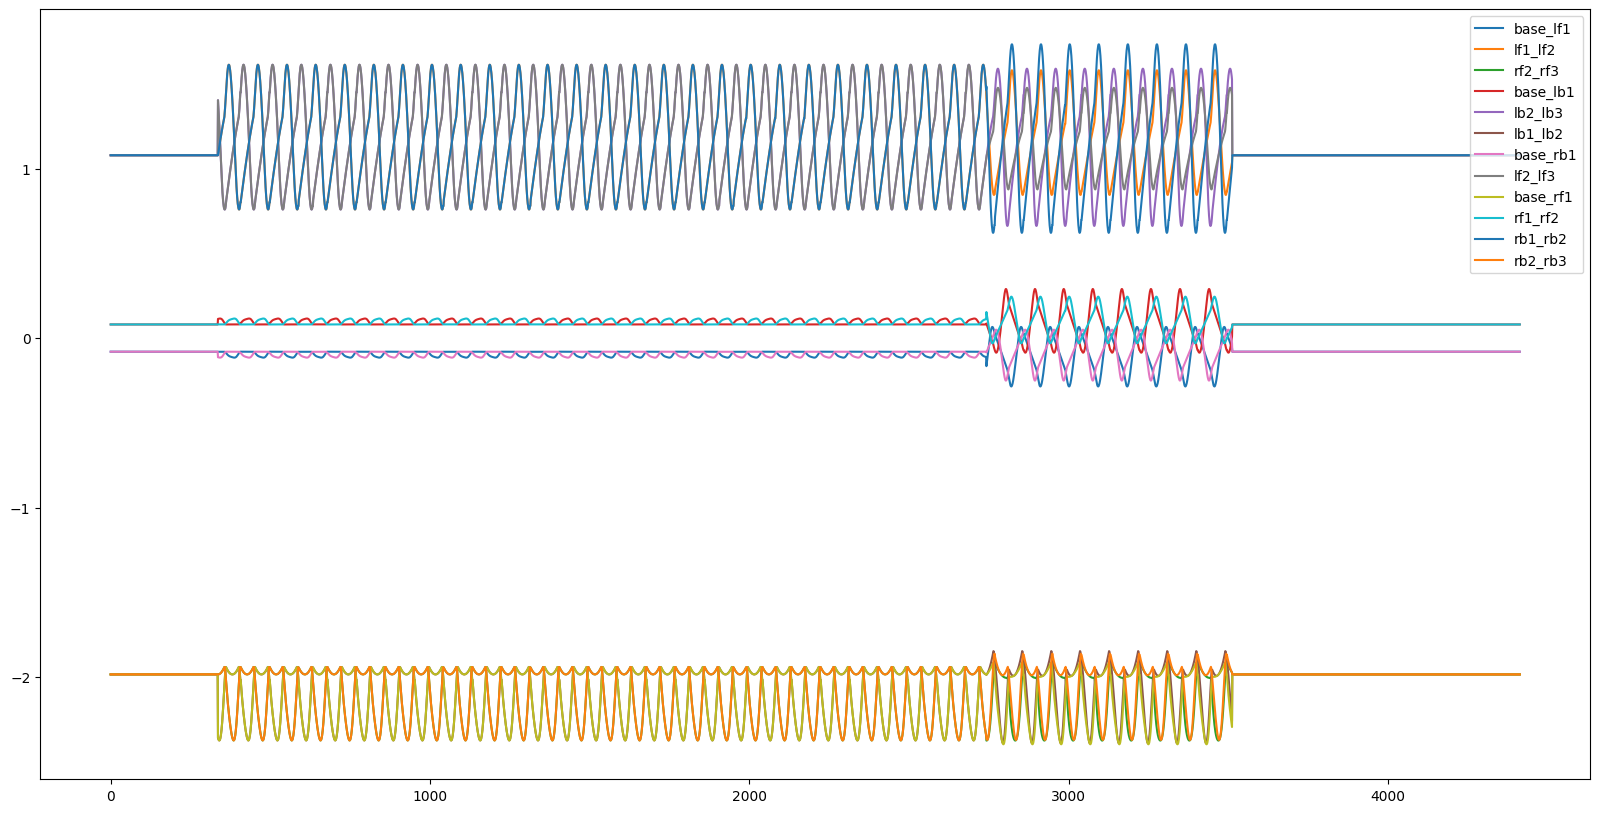

In [41]:
from rosidl_runtime_py.utilities import get_message
from rclpy.serialization import deserialize_message

# get joint_states
gaze_joint_states = pd.read_sql_query("SELECT * FROM messages WHERE topic_id=22", conn)
data = joint_states['data'].iloc[0]

def get_joint_names(d):
    return parse_joint(d).name

def parse_joint(d, idx=0):
    # Get the message class from the type string
    msg_type = get_message("sensor_msgs/msg/JointState")
    # Deserialize the message
    msg = deserialize_message(d, msg_type)
    return msg

print(parse_joint(data))

from matplotlib import pyplot as plt

fig, axes = plt.subplots(1, 1, figsize=(20, 10))

for j_id, j_name in enumerate(get_joint_names(gaze_data)):
    value = joint_states['data'].apply(lambda x: float(parse_joint(x).position[j_id]))
    axes.plot(value, label=j_name)

# axes.plot(joint_states['data'].apply(lambda x: float(parse_joint(x, 0))))
# axes.plot(joint_states['data'].apply(lambda x: float(parse_joint(x, 1))))
# axes.plot(joint_states['data'].apply(lambda x: float(parse_joint(x, 2))))
# axes.plot(joint_states['data'].apply(lambda x: float(parse_joint(x, 3))))
plt.legend()
plt.plot()


In [42]:
gazebo_data = "../../../ros2_log/pupper_rviz/pupper_rviz_0.db3"
conn = sqlite3.connect(gazebo_data)

tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table';", conn)

print(tables)

# print topic with id
topics = pd.read_sql_query("SELECT * FROM topics", conn)

# print all without collapsing
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

print(topics)

       name
0    schema
1  metadata
2    topics
3  messages
    id                                             name  \
0    1                                              /tf   
1    2                                        /odom/raw   
2    3                                          /rosout   
3    4                                            /odom   
4    5                                       /tf_static   
5    6                               /robot_description   
6    7  /joint_group_effort_controller/joint_trajectory   
7    8                                            /foot   
8    9                                /parameter_events   
9   10                                     /diagnostics   
10  11                                         /cmd_vel   
11  12                              /events/write_split   
12  13                          /base_to_footprint_pose   
13  14                                    /joint_states   
14  15                                     /initialpose

sensor_msgs.msg.JointState(header=std_msgs.msg.Header(stamp=builtin_interfaces.msg.Time(sec=1751511641, nanosec=665107581), frame_id=''), name=['base_lf1', 'lf1_lf2', 'lf2_lf3', 'base_rf1', 'rf1_rf2', 'rf2_rf3', 'base_lb1', 'lb1_lb2', 'lb2_lb3', 'base_rb1', 'rb1_rb2', 'rb2_rb3'], position=[-0.08031128346920013, 1.0780668258666992, -1.983426570892334, 0.08031131327152252, 1.0780668258666992, -1.983426570892334, -0.08031128346920013, 1.0780668258666992, -1.983426570892334, 0.08031131327152252, 1.0780668258666992, -1.983426570892334], velocity=[], effort=[])


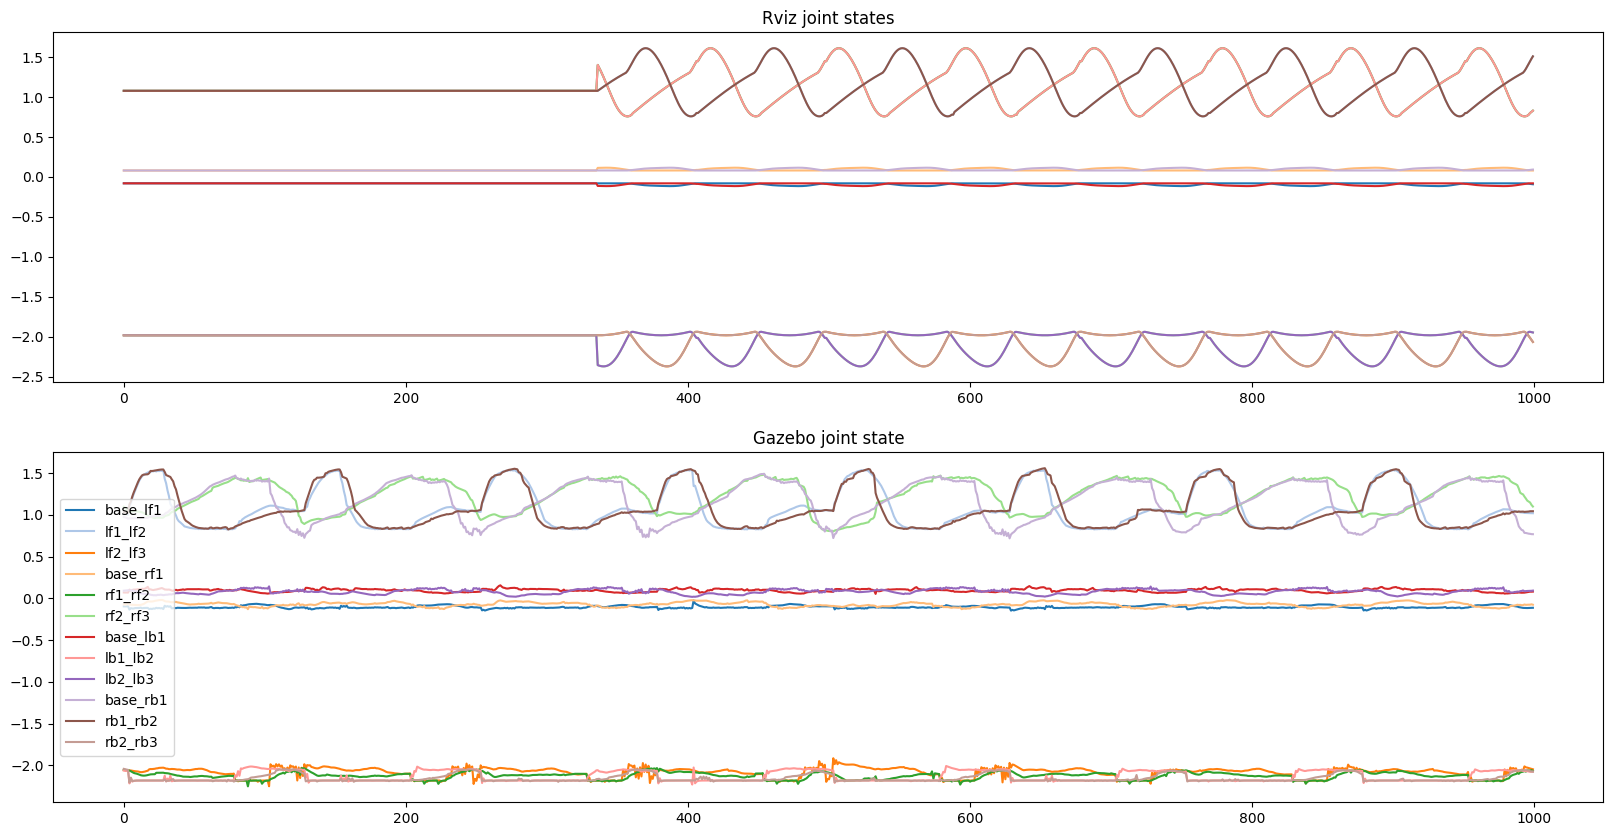

In [51]:
import matplotlib.cm as cm # For colormaps

# get joint_states
joint_states = pd.read_sql_query("SELECT * FROM messages WHERE topic_id=14", conn)
data = joint_states['data'].iloc[0]
colors_tab20 = [cm.tab20(i) for i in range(12)]


def get_joint_names(d):
    return parse_joint(d).name

def parse_joint(d, idx=0):
    # Get the message class from the type string
    msg_type = get_message("sensor_msgs/msg/JointState")
    # Deserialize the message
    msg = deserialize_message(d, msg_type)
    return msg

print(parse_joint(data))

from matplotlib import pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(20, 10))

for j_id, j_name in enumerate(get_joint_names(data)):
    value_gz = gaze_joint_states['data'].apply(lambda x: float(parse_joint(x).position[j_id]))
    value = joint_states['data'].apply(lambda x: float(parse_joint(x).position[j_id]))
    axes[0].set_title("Rviz joint states")
    axes[0].plot(value[:1000], label=j_name, c=colors_tab20[j_id])

    axes[1].set_title("Gazebo joint state")
    axes[1].plot(value_gz[:1000], label=j_name, c=colors_tab20[j_id])
    plt.legend()
    
# axes.plot(joint_states['data'].apply(lambda x: float(parse_joint(x, 0))))
# axes.plot(joint_states['data'].apply(lambda x: float(parse_joint(x, 1))))
# axes.plot(joint_states['data'].apply(lambda x: float(parse_joint(x, 2))))
# axes.plot(joint_states['data'].apply(lambda x: float(parse_joint(x, 3))))

plt.plot()

plt.savefig("servo_hist.png")